In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# path location parameters
results_path = "../../../results/brinkman_parameters/testing/"
meshed_path = "meshed/"
brinkman_path = "brinkman/"
BL_name = 'BL_60.csv'

# user variables
time_threshold = 150 # time until transience has finished
steps_between_velocity_vectors = 1 
scaling_velocity_vectors= 1
max_plot = False # plot max or min?
r_location = 0.55


In [2]:

# Define the all_info function as before
def all_info(x_index, t, x_coords, y_coords, time, u, v, w, p, n):
    if x_index < 0 or x_index >= len(x_coords):
        raise ValueError("x_index is out of bounds")

    base_index = x_index
    time_closest_index = time[x_index::n]
    time_closest_index.reset_index(drop=True, inplace=True)
    time_index = np.argmin(np.abs(time_closest_index - t))

    u_closest_index = u[x_index::n]
    u_closest_index.reset_index(drop=True, inplace=True)
    v_closest_index = v[x_index::n]
    v_closest_index.reset_index(drop=True, inplace=True)
    w_closest_index = w[x_index::n]
    w_closest_index.reset_index(drop=True, inplace=True)
    p_closest_index = p[x_index::n]
    p_closest_index.reset_index(drop=True, inplace=True)
    
    angle_radians = np.arctan(y_coords[x_index]/x_coords[x_index])
    #print("angle_radians=",angle_radians, "np.degrees(angle_radians)= ", np.degrees(angle_radians))
    # Radial velocity u_r
    u_r = u_closest_index[time_index]*np.cos(angle_radians) + v_closest_index[time_index]*np.sin(angle_radians)
    # Tangential velocity u_theta
    u_theta = u_closest_index[time_index]*np.sin(angle_radians) - v_closest_index[time_index]*np.cos(angle_radians)
    #print("u_closest_index[time_index]=",u_closest_index[time_index], "v_closest_index[time_index]=", v_closest_index[time_index], "u_r=", u_r, "u_theta=", u_theta)

    return time_closest_index[time_index], u_closest_index[time_index], v_closest_index[time_index], w_closest_index[time_index], p_closest_index[time_index], u_r, u_theta, angle_radians


def get_bl_plot(input_filename):
    # Read the first line to get the number of points
    with open(input_filename, 'r') as file:
        first_line = file.readline().strip()
        n = int(first_line.split(',')[0])  # Extract the first value as the number of points
    
    # Read coordinates
    
    coordinates = pd.read_csv(input_filename, skiprows=1, nrows=n, header=None)
    x_coords = coordinates.values[:, 0]  # All x-coordinates (first column)
    y_coords = coordinates.values[:, 1]  # All y-coordinates (second column)
    
    # Read the data from row n+1 onwards
    data = pd.read_csv(input_filename, skiprows=n + 1, header=None)
    
    # Extract time and variable columns
    time = data[0]  # Column A is time
    u = data[1] # Column B is u
    v = data[2] # Column C is v
    w = data[3] # Column D is w
    p = data[4] # Column E is p
    # print ("data.shape[1]=" , data.shape[1])
    if data.shape[1] > 8:
        dudx = data[5]     # Column F is dudx
        dudy = data[6]     # Column G is dudy
        dvdx = data[7]     # Column H is dvdx
        dvdy = data[8]     # Column I is dvdy
        derivative_available = True
    print("Loading data from file (",os.path.basename(input_filename),") successfully done. n= ", n, " points/probs detected.")

    r_all = np.sqrt((x_coords)**2 + (y_coords)**2)
    r_index = np.argmin(np.abs(r_all - r_location))
    print(r_index)
    prob_index = r_index

    time_per_prob = time[prob_index::n]
    time_per_prob.reset_index(drop=True, inplace=True)
    
    u_per_prob = u[prob_index::n]
    u_per_prob.reset_index(drop=True, inplace=True)
    
    v_per_prob = v[prob_index::n]
    v_per_prob.reset_index(drop=True, inplace=True)
    w_per_prob = w[prob_index::n]
    w_per_prob.reset_index(drop=True, inplace=True)
    p_per_prob = p[prob_index::n]
    p_per_prob.reset_index(drop=True, inplace=True)
    
    angle_radians = np.arctan(y_coords[prob_index]/x_coords[prob_index])
    # Radial velocity u_r
    u_r = u_per_prob*np.cos(angle_radians) + v_per_prob*np.sin(angle_radians)
    # Tangential velocity u_theta
    u_theta = u_per_prob*np.sin(angle_radians) - v_per_prob*np.cos(angle_radians)
    
    '''
    # Find the index of the maximum value
    max_index = np.argmax(u_theta)
    # Find the index of the minimum value
    min_index = np.argmin(u_theta)
    '''
    # Create a mask for indices where time_per_prob is greater than the threshold
    mask = time_per_prob > time_threshold
    
    # Apply the mask to u_theta to get the values that meet the threshold condition
    filtered_u_theta = u_theta[mask]
    filtered_time_per_prob = time_per_prob[mask]
    
    # Find the max and min indices in the filtered arrays
    filtered_max_index = np.argmax(filtered_u_theta)
    filtered_min_index = np.argmin(filtered_u_theta)
    
    # Map the filtered indices back to the original indices
    max_index = np.where(mask)[0][filtered_max_index]
    min_index = np.where(mask)[0][filtered_min_index]
    print("time_per_prob[max_index]= ", time_per_prob[max_index], "u_theta[max_index]= ", u_theta[max_index])
    print("time_per_prob[min_index]= ", time_per_prob[min_index], "u_theta[min_index]= ", u_theta[min_index])

    if max_plot == True:
        t_index = max_index
    else:
        t_index = min_index
    
    
    input_time = time_per_prob[t_index]

    
    r_list = []
    u_theta_list = []
    for i in np.arange(0, n, 1):
        x0, y0 = x_coords[i], y_coords[i]
        closest_time, x1, y1, _, _, u_r, u_theta, angle_radians= all_info(i, input_time, x_coords, y_coords, time, u, v, w, p, n)
        
        u_theta_list.append(u_theta)
        r_list.append(np.sqrt((x_coords[i])**2 + (y_coords[i])**2))
    
    r_plot = np.array(r_list)
    u_theta_plot = np.array(u_theta_list)

    return r_plot, u_theta_plot



In [3]:
input_filename = results_path+brinkman_path+BL_name
brinkman_r_plot, brinkman_u_theta_plot = get_bl_plot(input_filename)
input_filename = results_path+meshed_path+BL_name
meshed_r_plot, meshed_u_theta_plot = get_bl_plot(input_filename)

Loading data from file ( BL_60.csv ) successfully done. n=  400  points/probs detected.
239
time_per_prob[max_index]=  216.50249999983936 u_theta[max_index]=  0.0014916003105185376
time_per_prob[min_index]=  255.30249999980407 u_theta[min_index]=  -0.004999041036232075
Loading data from file ( BL_60.csv ) successfully done. n=  200  points/probs detected.
40
time_per_prob[max_index]=  254.70249999980464 u_theta[max_index]=  0.06944327894281735
time_per_prob[min_index]=  156.40249999989402 u_theta[min_index]=  -0.03154511705568724


# Plotting

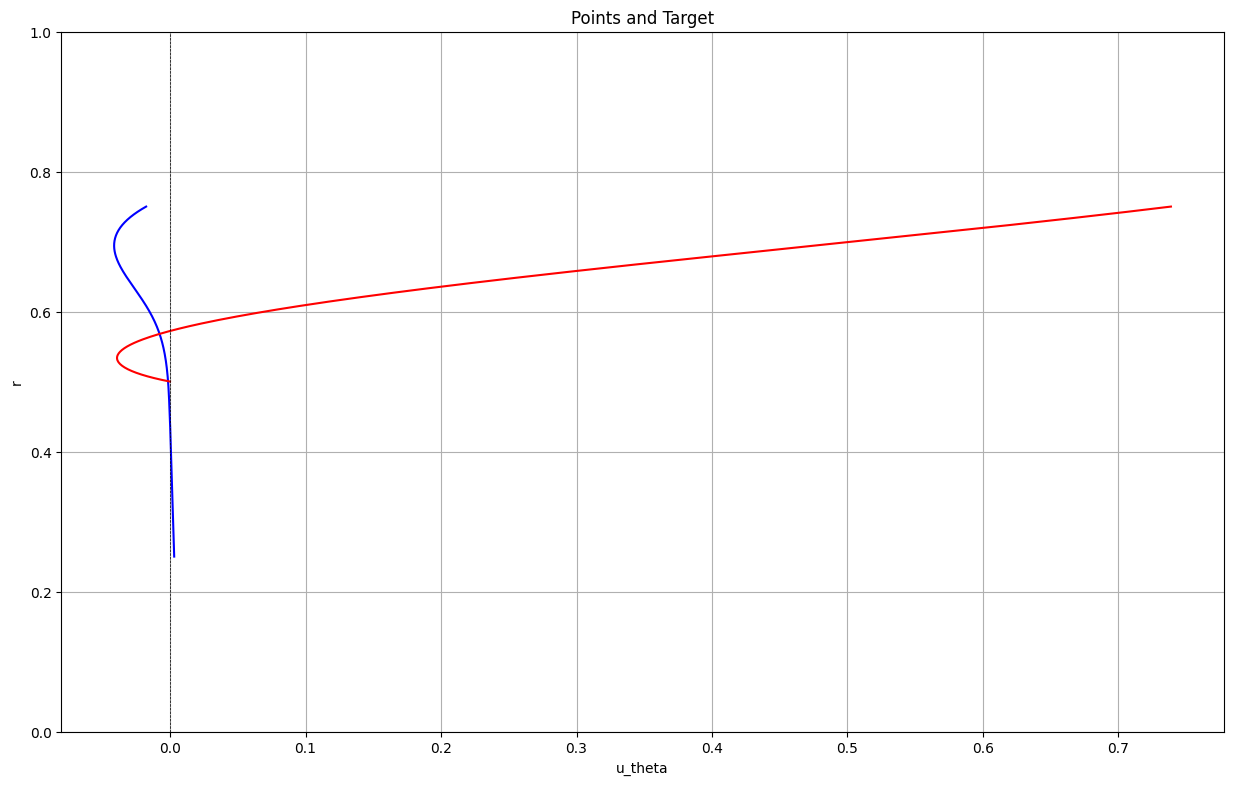

In [4]:


# Create a single figure for 2 subplots
fig = plt.figure(figsize=(15, 20))
#plt.suptitle(input_filename, fontsize=18, y=0.95)

# First subplot
plt.subplot(2, 1, 1)

plt.plot(brinkman_u_theta_plot, brinkman_r_plot, color='blue') 
plt.plot(meshed_u_theta_plot, meshed_r_plot, color='red') 

#plt.xlim(-1, 1)
plt.ylim(0, 1)
plt.title('Points and Target')
plt.xlabel('u_theta')
plt.ylabel('r')
plt.axhline(0, color='black', linewidth=0.5, ls='--')
plt.axvline(0, color='black', linewidth=0.5, ls='--')
plt.grid()
#plt.gca().set_aspect('equal', adjustable='box')
plt.show()